In [22]:
#linear regression code 
#%pip install pandas matplotlib

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline


In [24]:
df = pd.read_csv('height-weight.csv')
print(df.head())

   Weight  Height
0      45     120
1      58     135
2      48     123
3      60     145
4      70     160


Text(0, 0.5, 'Height')

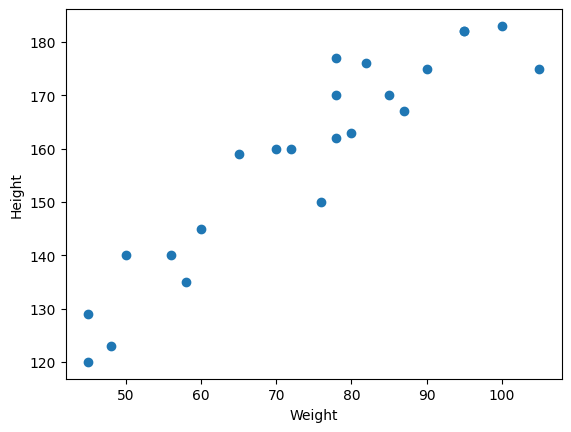

In [25]:
#first thing is to understand the realtionship between weight and height,
#check how you independent features are releated, whehter they are corelated properly
#one way is to use scatter plot
plt.scatter(df['Weight'], df['Height']) #as the weight is increasing the height is also increasing
plt.xlabel("Weight")
plt.ylabel("Height")

In [26]:
#correlation
df.corr() #pearson co realtion

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


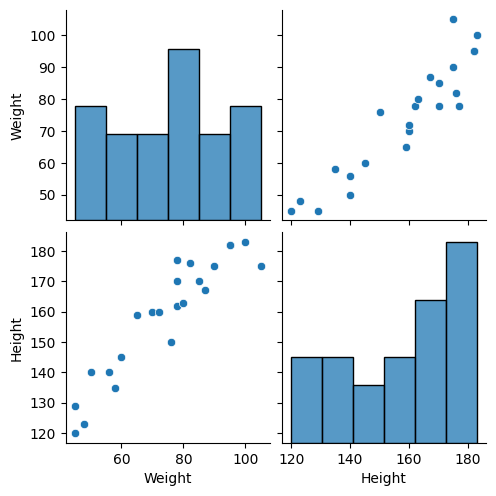

In [27]:
#seaborn for visulization
#%pip install seaborn
import seaborn as sns
sns.pairplot(df)

In [28]:
#first step
#divide feature into independent and dependent features
X=df[['Weight']]#always use two dimensonal array for independent feature, super importtant when trnaing a model
#np.array(X).shape # check for dimensons
y=df['Height']
#np.array(y).shape

In [29]:
#%pip install scikit-learn

In [30]:
#Train Test SPlit
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.25)
X_train.shape

(17, 1)

In [31]:
#Standardization: we take up each value of independent feature and we apply z_score
#converting all you  values with mean = 0 and standard deation = 1
#units are different for x and y x in kgs  and y in cms

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [32]:
#why do we use  transform and fit_transform , because of data leakage , related to z score
X_test  = scaler.fit_transform(X_test)
X_test

array([[-0.32038535],
       [ 1.39410922],
       [-1.72315364],
       [ 0.19915846],
       [ 0.87456541],
       [-0.42429411]])

In [33]:
#Apply linear regression
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
print("regression.coef_:",regression.coef_) # 1 unit  movement in y axis leads to 17.29 unit movements in x axis
print("regression.intercept_:", regression.intercept_) #when the weight value is zero, wheb at what point your line is meeting the y axis

regression.coef_: [18.11973849]
regression.intercept_: 156.52941176470588


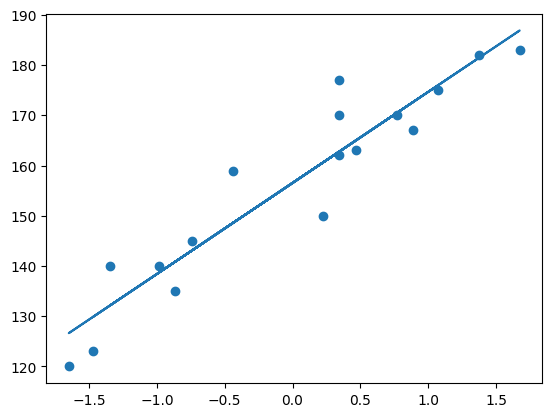

In [35]:
#plot Traning data  best fit line
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train))


In [36]:
#prediction for test data
y_pred = regression.predict(X_test)

In [37]:
#preformace metrice
from sklearn.metrics import mean_absolute_error, mean_squared_error
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)


102.42081206221035
9.400690338900846
10.120316796534105


In [38]:
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
print(score)

0.6669843538439693


In [39]:
#adjusted r square
1-(1-score)*(len(y_test)-1/len(y_test)-X_test.shape[1]-1)

-0.27655997693145107

In [40]:
#OLS linear regression
#%pip install statsmodels
import  statsmodels.api as sm
model = sm.OLS(y_train,X_train).fit()
prediction = model.predict(X_test)
print(prediction)

[ -5.80529875  25.26089455 -31.22309326   3.60869922  15.84689658
  -7.68809834]


In [41]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.013
Model:                            OLS   Adj. R-squared (uncentered):             -0.048
Method:                 Least Squares   F-statistic:                             0.2140
Date:                Sun, 26 Apr 2026   Prob (F-statistic):                       0.650
Time:                        00:06:40   Log-Likelihood:                         -110.04
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [46]:
print(regression.predict([[72]]))
regression.predict(scaler.transform([[72]]))

[1461.15058275]


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([150.72411302])